# RedRock Email Classification — Calibration

Trains the final model, then calibrates it with Platt scaling (sigmoid) via `CalibratedClassifierCV`. Logic lives in `src/modelling.py` and `src/calibration.py`; this notebook only calls it and inspects results.

In [2]:
import sys
sys.path.append("..")
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import src.ingestion, src.preprocessing, src.features, src.modelling, src.calibration
importlib.reload(src.ingestion)
importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.modelling)
importlib.reload(src.calibration)

from src.ingestion import build_dataframe, load_labels
from src.preprocessing import add_clean_text_column
from src.features import add_engineered_features
from src.modelling import (STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS,
                            build_text_pipeline, compare_models, train_and_save_best_model)
from src.calibration import build_calibrated_pipeline, evaluate_calibration_performance, save_calibrated_model

## 1. Load data

In [3]:
BASE_DIR = Path(r"C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier")
TRAIN_DIR, LABELS_PATH = BASE_DIR / "train", BASE_DIR / "train_labels.csv"
MODELS_DIR = BASE_DIR / "outputs" / "models"

train_df = build_dataframe(TRAIN_DIR)
labels_df = load_labels(LABELS_PATH)
train_labeled = train_df.merge(labels_df, left_on="source_filename", right_on="filename", how="left")
train_labeled = add_clean_text_column(train_labeled)
train_labeled = add_engineered_features(train_labeled)

y = train_labeled["true_category"]
X = train_labeled[["subject", "message"] + STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS]
print(f"Data loaded: {len(train_labeled)} emails")

Data loaded: 44 emails


## 2. Confirm the winning model/representation via CV

(Already established in `02_modelling.ipynb`: Linear SVM on separated subject/message TF-IDF. Re-run here for a self-contained record.)

In [4]:
model_results = compare_models(X, y, ("subject", "message"))
for name, (mean_f1, std_f1) in model_results.items():
    print(f"{name}: F1-macro = {mean_f1:.3f} (+/- {std_f1:.3f})")

logistic_regression: F1-macro = 0.894 (+/- 0.107)
linear_svm: F1-macro = 0.947 (+/- 0.076)
naive_bayes: F1-macro = 0.655 (+/- 0.070)


## 3. Train and persist the final (uncalibrated) model

In [6]:
best_pipeline, metadata = train_and_save_best_model(train_labeled, y, MODELS_DIR)
print(f"Best model saved: {metadata['model_type']} with {metadata['text_representation']} text")
print(f"F1-macro: {metadata['f1_macro_cv_mean']:.3f} (+/- {metadata['f1_macro_cv_std']:.3f})")

Best model saved: LinearSVC with separated text
F1-macro: 0.947 (+/- 0.076)


## 4. Calibrate (Platt scaling) and evaluate

`sigmoid` is used rather than `isotonic`: isotonic regression tends to overfit on very small datasets (N=44). `cv=3` (not 5) is used for the internal calibration folds, since the smallest classes (6 examples) leave too few points per fold at cv=5.

--- Brier Score Comparison (Lower is better) ---
Account Management        | Raw Brier: 0.071 -> Calibrated Brier: 0.061 (+13.6%)
Insurance Claims          | Raw Brier: 0.019 -> Calibrated Brier: 0.012 (+37.0%)
Investment Advisory       | Raw Brier: 0.084 -> Calibrated Brier: 0.082 (+1.5%)
Loan Processing           | Raw Brier: 0.085 -> Calibrated Brier: 0.048 (+43.1%)
Other                     | Raw Brier: 0.035 -> Calibrated Brier: 0.023 (+35.4%)


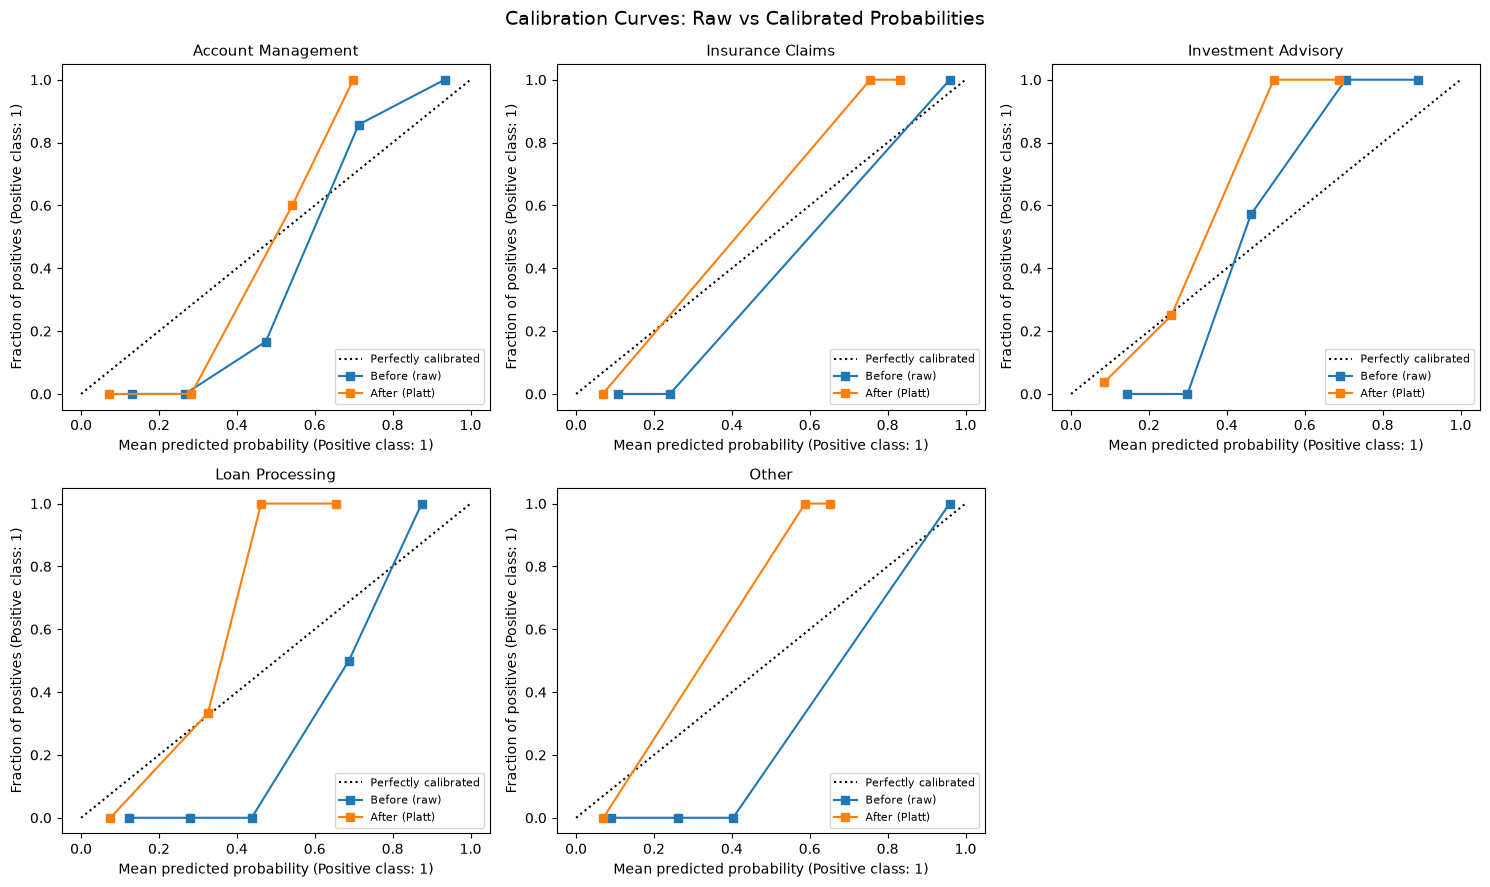


Average improvement: 26.1%


In [7]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

base_clf = LinearSVC(class_weight="balanced", random_state=42)
calibrated_clf = CalibratedClassifierCV(base_clf, method="sigmoid", cv=3)
calibrated_pipeline = build_text_pipeline(("subject", "message"), STRUCTURED_BOOL_COLS,
                                           STRUCTURED_NUM_COLS, calibrated_clf)
calibrated_pipeline.fit(X, y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
brier_improvements, class_names = evaluate_calibration_performance(
    X, y, best_pipeline, calibrated_pipeline, skf
)

## 5. Save the calibrated model

In [8]:
metadata = save_calibrated_model(calibrated_pipeline, MODELS_DIR, metadata,
                                  brier_improvements, class_names)
print(f"Average Brier improvement: {metadata['average_brier_improvement']:.1f}%")

Average Brier improvement: 26.1%
